# Import Dataset


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
import os

if os.path.exists("/content/drive"):
    # Google Colab
    PROJECT_ROOT = "/content/drive/MyDrive/IndividualProject"
else:
    # Local / GitHub
    PROJECT_ROOT = os.path.dirname(os.getcwd())

sys.path.append(os.path.join(PROJECT_ROOT, "src"))
from evaluation import youden_threshold, gender_disparity, auc_by_sex, age_disparity, auc_by_age, intersectional_disparity, auc_by_intersection

In [3]:
BASE_DIR = "/content/drive/MyDrive/IndividualProject/cxr"

In [4]:
# import the required libraries
import numpy as np
import pandas as pd
import os
import ast

In [5]:
# import the processed dataset
processed_df = pd.read_csv(BASE_DIR + "/processed_data_v3.csv")
processed_df.head()

,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position,tasks/atelectasis_label,tasks/pneumonia_label
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA,0,0
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA,0,0
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA,0,0
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA,0,0
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA,0,0


Retrive the train, validation, test splits.

In [6]:
# read the images in the train set
with open(BASE_DIR + "/splits/train.txt", "r") as f:
    train_list = [image_filepath.strip() for image_filepath in f]

# retrieve the entries in the train split and convert them into a DataFrame
train_df = processed_df[processed_df["filepath"].isin(train_list)]

# repeat the same process for validation set
with open(BASE_DIR + "/splits/val.txt", "r") as f:
    val_list = [image_filepath.strip() for image_filepath in f]

val_df = processed_df[processed_df["filepath"].isin(val_list)]

# repeat the same for test set
with open(BASE_DIR + "/splits/test.txt", "r") as f:
    test_list = [image_filepath.strip() for image_filepath in f]

test_df = processed_df[processed_df["filepath"].isin(test_list)]


# Baseline Training

In [7]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import h5py
import torch.nn.functional as F
from PIL import Image
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, recall_score

In [8]:
# reference: https://github.com/mvsjober/pytorch-hdf5/blob/master/pytorch_dvc_cnn.py on how to read hdf5 with pytorch
class ChestXRayDataset(Dataset):

    def __init__(self, df, labels_col, hdf5_path, transform=None):
        self.df = df
        self.labels_col = labels_col
        self.hdf5_path = hdf5_path
        self.transform = transform

        self.h5 = h5py.File(self.hdf5_path, "r")
        self.images = self.h5["images"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        original_index = self.df.index[idx]

        img = self.images[original_index]

        img = torch.tensor(img, dtype=torch.float32)

        # normalise the image if not already done so
        if img.max() > 1:
            img = img / 255.0

        img = img.unsqueeze(0).repeat(3,1,1)

        if self.transform:
            img = self.transform(img)

        # disease
        y = float(self.df.iloc[idx][self.labels_col])
        label = torch.tensor([y], dtype=torch.float32)

        # sex
        sex = torch.tensor(self.df.iloc[idx]['tasks/patient sex'], dtype=torch.float32)

        # age
        raw_age = self.df.iloc[idx]['patient_age']

        if raw_age >= 50:
          age_binary = 1
        else:
          age_binary = 0

        age = torch.tensor(age_binary, dtype=torch.long)

        return img, label, sex, age


Peform data augmentation

In [9]:
# data augmentation process
from torchvision import transforms

# transform function for train set
train_transform = transforms.Compose([
    # perform horizontal flip, rotation and normalize
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

]
)

# trasform function for validation set
valid_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transform function for test set
test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [10]:
HDF5_PATH = "/content/drive/MyDrive/IndividualProject/cxr/images.hdf5"

train_dataset = ChestXRayDataset(
    df = train_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = train_transform
)

valid_dataset = ChestXRayDataset(
    df = val_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = valid_transform
)

test_dataset = ChestXRayDataset(
    df = test_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = test_transform
)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True,
    num_workers = 0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 0,
    pin_memory=True
)

In [12]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# pos_weight
pos = float((train_df["tasks/atelectasis_label"] == 1).sum())
neg = float((train_df["tasks/atelectasis_label"] == 0).sum())
pos_weight = torch.tensor([neg/ pos], device =DEVICE)

# using binary cross entropy with logits loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

num_features = model.classifier.in_features
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 1))
model = model.to(DEVICE)

learning_rate = 5e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

Device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 226MB/s]


In [13]:
from tqdm import tqdm
def train_one_epoch(model, loader, criterion, optimizer, device):

  model.train()
  training_loss = 0.0

  # use tqdm to show the training progress
  loop = tqdm(loader, desc="Training", leave=False)

  for images, labels, *_ in loop:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
      # compute the loss
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    training_loss += loss.item()

  avg_training_loss = training_loss/len(loader)

  return avg_training_loss

In [14]:
def validate(model, loader, criterion, device):
    model.eval()
    validation_loss = 0.0
    all_preds = []
    all_labels = []

    # disable gradient calculation
    with torch.no_grad():
      loop = tqdm(loader, desc="Validation", leave=False)

      for images, labels, *_ in loop:
          images = images.to(device)
          labels = labels.to(device)

          outputs = model(images)
          loss = criterion(outputs, labels)

          validation_loss += loss.item()

          all_preds.append(torch.sigmoid(outputs).cpu())
          all_labels.append(labels.cpu())


    avg_validation_loss = validation_loss / len(loader)
    all_preds = torch.cat(all_preds).numpy().reshape(-1)
    all_labels = torch.cat(all_labels).numpy().reshape(-1)

    # compute the auc score directly
    auc = roc_auc_score(all_labels, all_preds)

    return avg_validation_loss, all_preds, all_labels, auc


In [15]:
# function to save the model in case the training was disrupted
def save_checkpoint(epoch, model, optimizer, learning_rate, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'learning_rate': learning_rate
    }
    torch.save(checkpoint, filename)

Main Training Loop

In [ ]:
from datetime import datetime
EPOCHS = 30
best_val = -1.0
patience = 5
min_delta = 0.001
epochs_no_improve = 0
training_loss, validation_loss, validation_auc = [], [], []

# save for model checkpoint
for epoch in range(1, EPOCHS+1):

    # train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    # validate
    val_loss, val_preds, val_labels, val_auc = validate(model, valid_loader, criterion, DEVICE)

    training_loss.append(train_loss)
    validation_loss.append(val_loss)
    validation_auc.append(val_auc)

    scheduler.step(val_auc)

    print(f"Epoch {epoch}/{EPOCHS} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

    # implement early stopping
    if  val_auc > best_val + min_delta:
        best_val = val_auc
        best_epoch = epoch
        epochs_no_improve = 0
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        torch.save(model.state_dict(), f"/content/drive/MyDrive/IndividualProject/best_model_binary_atelectasis_{timestamp}.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping: no validation AUC improvement for {patience} epochs.")
            break

    save_checkpoint(epoch, model, optimizer, learning_rate, f"checkpoint_epoch_{epoch}.pth")


In [ ]:
# save the best result
import json
import os
from datetime import datetime

SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Create training history dictionary
training_history = {
    'model_name': 'baseline_densenet121',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'hyperparameters': {
        'epochs': EPOCHS,
        'batch_size': 64,
        'learning_rate': learning_rate,
        'weight_decay': 1e-4,
        'optimizer': 'Adam',
        'scheduler': 'ReduceLROnPlateau',
        'patience': patience,
        'pos_weight': float(pos_weight.cpu().item()) if torch.is_tensor(pos_weight) else float(pos_weight)
    },
    'dataset_sizes': {
        'train': len(train_df),
        'validation': len(val_df),
        'test': len(test_df)
    },
    'training_curves': {
        'epochs': list(range(1, len(training_loss) + 1)),
        'train_loss': [float(x) for x in training_loss],
        'val_loss': [float(x) for x in validation_loss],
        'val_auc': [float(x) for x in validation_auc]
    },
    'best_model': {
        'epoch': best_epoch if 'best_epoch' in locals() else int(np.argmax(validation_auc)) + 1,
        'val_auc': float(max(validation_auc)),
        'val_loss': float(validation_loss[np.argmax(validation_auc)])
    },
    'early_stopping': {
        'triggered': epochs_no_improve >= patience,
        'stopped_at_epoch': len(training_loss)
    }
}

# Save as JSON
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
history_file = f"{SAVE_DIR}/baseline_training_history_atelectasis_{timestamp}.json"
with open(history_file, 'w') as f:
    json.dump(training_history, f, indent=4)

# Graph Plotting

In [16]:
import json

BASE_PATH = "/content/drive/MyDrive/IndividualProject/results"

with open(f"{BASE_PATH}/baseline_training_history_atelectasis_20260215_022904.json", 'r') as f:
    training_history = json.load(f)

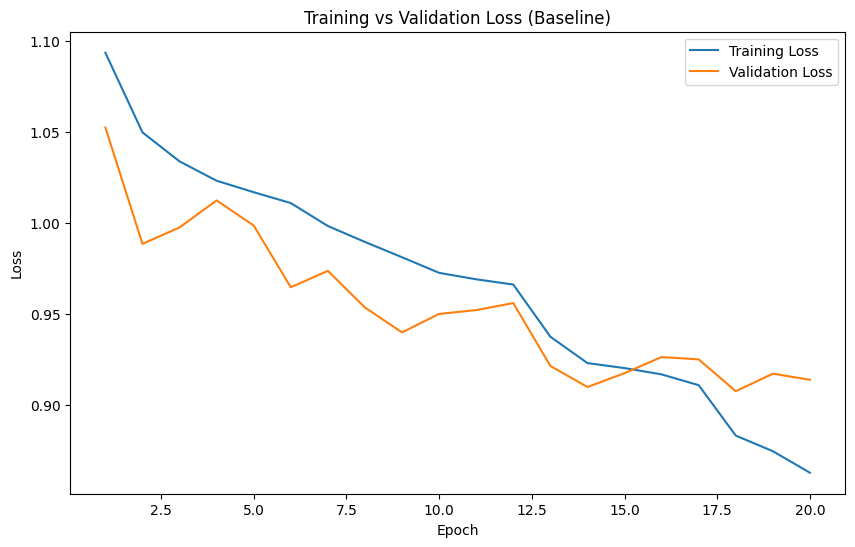

In [17]:
# plot training_loss  v.s. validation loss
import matplotlib.pyplot as plt

training_loss = training_history["training_curves"]['train_loss']
validation_loss = training_history["training_curves"]['val_loss']

total_epochs = len(training_loss)

plt.figure(figsize=(10, 6))
plt.plot(range(1, total_epochs+1), training_loss, label="Training Loss")
plt.plot(range(1, total_epochs+1), validation_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Baseline)")
plt.legend()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/training_vs_validation_loss_{timestamp}.png")
plt.show()

/tmp/ipykernel_4496/3908846637.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


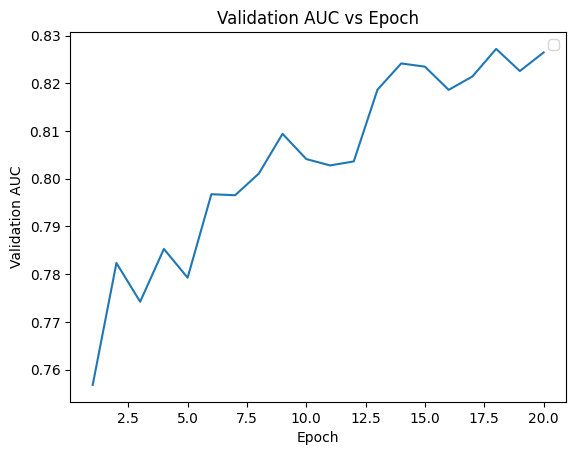

In [18]:
validation_auc = training_history["training_curves"]['val_auc']

plt.figure()
plt.plot(range(1, total_epochs+1), validation_auc)

plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC vs Epoch")
plt.legend()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/validation_auc_vs_epoch_{timestamp}.png")
plt.show()

# Evaluation


In [ ]:

# load the best model and apply it on the test set
BEST_MODEL_PATH =  "/content/drive/MyDrive/IndividualProject/best_model_binary_atelectasis.pth"

# recreate the model
model = models.densenet121(weights=None)
num_features = model.classifier.in_features
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 1))
model = model.to(DEVICE)
best_model = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(best_model)
model.eval()

val_loss, val_probs, val_labels, val_auc = validate(model, valid_loader, criterion, DEVICE)

# compute Youden's Index using the validation dataset
best_threshold_youden = youden_threshold(val_labels, val_probs)
print("Best threshold: ", best_threshold_youden)

test_loss, test_probs, test_labels, test_auc = validate(model, test_loader, criterion, DEVICE)

# print out the result
print(f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")

# compute tpr for sex
test_gender_gap = gender_disparity(test_probs, test_labels, test_df, threshold=best_threshold_youden)
print("Gender gap:", test_gender_gap)

# compute tpr for age
test_age_gap = age_disparity(test_probs, test_labels, test_df, threshold=best_threshold_youden)
print("Age gap:", test_age_gap)

# compute auc for sex
test_auc_by_sex = auc_by_sex(test_probs, test_labels, test_df)
print("AUC by sex:", test_auc_by_sex)

# compute auc for age
test_auc_by_age = auc_by_age(test_probs, test_labels, test_df)
print("AUC by age:", test_auc_by_age)

# compute tpr for intersectional group
test_intersectional_tpr = intersectional_disparity(test_probs, test_labels, test_df, threshold = best_threshold_youden)
print("Intersectional TPR disparity:", test_intersectional_tpr)

# compute auc for intersectional group
test_intersection_auc = auc_by_intersection(test_probs, test_labels, test_df)
print("Intersectional AUC:", test_intersection_auc)


Best threshold:  0.5437869


Test Loss: 1.1993 | Test AUC: 0.7605
Gender gap: {'atelectasis': {'tpr_male': 0.7698, 'tpr_female': 0.7197, 'tpr_disparity': 0.0501, 'male_samples': 14882, 'female_samples': 10714, 'total_samples': 25596}}
Age gap: {'atelectasis': {'tpr_young': 0.6969, 'tpr_old': 0.7901, 'tpr_disparity': 0.0932, 'young_samples': 13167, 'old_samples': 12429, 'total_samples': 25596}}
AUC by sex: {'atelectasis': {'auc_male': 0.7734, 'auc_female': 0.7415, 'auc_gap': 0.0319, 'male_samples': 14882, 'female_samples': 10714, 'total_samples': 25596}}
AUC by age: {'atelectasis': {'auc_young': 0.7723, 'auc_old': 0.7446, 'auc_gap': -0.0277, 'young_samples': 13167, 'old_samples': 12429, 'total_samples': 25596}}
Intersectional TPR disparity: {'atelectasis': {'tpr_per_group': {'male_<50': 0.7166, 'male_>=50': 0.8087, 'female_<50': 0.6719, 'female_>=50': 0.7617}, 'median_tpr': 0.7391, 'gap_per_group': {'male_<50': -0.0226, 'male_>=50': 0.0695, 'female_<50': -0.0672, 'female_>=50': 0.0226}, 'max_min_tpr_gap': 0.1368, '

Save the evaluation results to `results/` folder for future reference.

In [ ]:
import json
import pandas as pd
from datetime import datetime

# save results
SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Create results dictionary
baseline_results = {
    'model_name': 'baseline_densenet121',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'dataset_size': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df)
    },
    'test_metrics': {
        'test_loss': float(test_loss),
        'test_auc': float(test_auc),
        'threshold': float(best_threshold_youden)
    },
    'fairness_metrics': {
        'tpr_male': test_gender_gap['atelectasis']['tpr_male'],
        'tpr_female': test_gender_gap['atelectasis']['tpr_female'],
        'tpr_disparity': test_gender_gap['atelectasis']['tpr_disparity'],
        'auc_male': test_auc_by_sex['atelectasis']['auc_male'],
        'auc_female': test_auc_by_sex['atelectasis']['auc_female'],
        'auc_gap': test_auc_by_sex['atelectasis']['auc_gap'],
        'tpr_young': test_age_gap['atelectasis']['tpr_young'],
        'tpr_old': test_age_gap['atelectasis']['tpr_old'],
        'tpr_disparity:': test_age_gap['atelectasis']['tpr_disparity'],
        'auc_young': test_auc_by_age['atelectasis']['auc_young'],
        'auc_old': test_auc_by_age['atelectasis']['auc_old'],
        'auc_gap': test_auc_by_age['atelectasis']['auc_gap']
    },
    'sample_distribution': {
        'male_samples': test_gender_gap['atelectasis']['male_samples'],
        'female_samples': test_gender_gap['atelectasis']['female_samples'],
        'young_samples': test_age_gap['atelectasis']['young_samples'],
        'old_samples': test_age_gap['atelectasis']['old_samples'],
        'total_samples': test_age_gap['atelectasis']['total_samples']
    }
}

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# Save as JSON
with open(f"{SAVE_DIR}/baseline_results_atelectasis_youden_original_{timestamp}.json", 'w') as f:
    json.dump(baseline_results, f, indent=4)
print(f"Results saved to {SAVE_DIR}/baseline_results_atelectasis_youden_original_{timestamp}.json")

# Sex Probing
How much sex information is encoded inside the learn features.

In [ ]:
# define extract features functions
def extract_features(model, loader, device):

  # set to eval() mode
  model.eval()
  all_features = []
  all_disease = []
  all_sex = []

  # enable torch.no_grad()
  with torch.no_grad():
    for imgs, label, sex, _ in loader:
      imgs = imgs.to(device)

      features = model.features(imgs)
      features = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))
      features = features.view(features.size(0), -1)

      all_features.append(features.cpu().numpy())
      all_disease.append(label.numpy())
      all_sex.append(sex.numpy())


  all_features = np.concatenate(all_features, axis=0)
  all_disease = np.concatenate(all_disease, axis=0)
  all_sex = np.concatenate(all_sex, axis=0)

  return all_features, all_disease, all_sex

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from scipy import stats
import numpy as np

# load the best model
baseline_model = models.densenet121(weights=None)
num_features = baseline_model.classifier.in_features
baseline_model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 1))
baseline_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/IndividualProject/best_model_binary_atelectasis.pth"
))
baseline_model = baseline_model.to(DEVICE)
baseline_model.eval()

# extract the features
X_train_features, y_train_disease, y_train_sex = extract_features(baseline_model, train_loader, DEVICE)

<class 'torchvision.models.densenet.DenseNet'>
Weight checksum: -16.0601


In [ ]:
# linear probing 5-fold cross validation function
def run_cv(X, y, n_splits=5, n_components=20):

  # stratified split to ensure class balance
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  aucs = []

  # loop through each fold
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    # retrieve the relevant indices for training and validation set
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # apply standard scaler on train set and transform on both train and validation set
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # apply PCA to retrieve the first 20 components only
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)

    # run the probing using LogisticRegression
    probe = LogisticRegression(max_iter=2000)
    probe.fit(X_train_pca, y_train.ravel())
    auc = roc_auc_score(y_val.ravel(), probe.predict_proba(X_val_pca)[:, 1])
    aucs.append(auc)
    print(f"Fold {fold+1}: AUC = {auc:.4f}")

  return np.array(aucs)

In [ ]:
# run linear probing and save to file
print("Baseline Sex - Linear Probing")
aucs_base_sex = run_cv(X_train_features, y_train_sex)
print(f"Mean: {aucs_base_sex.mean():.4f}")
print(f"Std:  {aucs_base_sex.std():.4f}")

path = '/content/drive/MyDrive/IndividualProject/cv_results/baseline'
np.save(f'{path}/lr_sex.npy', aucs_base_sex)
print("Saved!")

Baseline Sex - Linear Probing
Fold 1: AUC = 0.6932
Fold 2: AUC = 0.7009
Fold 3: AUC = 0.6934
Fold 4: AUC = 0.6929
Fold 5: AUC = 0.6998
Mean: 0.6960
Std:  0.0035
Saved!


Run comparison between the two models for linear probing.

In [ ]:
from scipy import stats
import numpy as np

# load the relevant file for comparison between two linear probing results
base = '/content/drive/MyDrive/IndividualProject/cv_results'

aucs_base_sex = np.load(f'{base}/baseline/lr_sex.npy')
aucs_dann_sex = np.load(f'{base}/dann_sex/lr_sex.npy')

t_statistic, p_value = stats.ttest_rel(aucs_base_sex, aucs_dann_sex)

print("Statistical Significance Test - Sex")
print(f"Baseline:{aucs_base_sex.mean():.4f} ± {aucs_base_sex.std():.4f}")
print(f"DANN-sex:{aucs_dann_sex.mean():.4f} ± {aucs_dann_sex.std():.4f}")
print(f"Gap:{aucs_base_sex.mean() - aucs_dann_sex.mean():.4f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value:{p_value:.4f}")
print(f"p-value:{p_value:.6f}")
print(f"p-value:{p_value:.2e}")

Statistical Significance Test - Sex
Baseline:0.6960 ± 0.0035
DANN-sex:0.5577 ± 0.0024
Gap:0.1384
t-statistic: 49.7547
p-value:0.0000
p-value:0.000001
p-value:9.76e-07


Probing test using SVM

In [ ]:
from sklearn.svm import SVC
def run_cv_svm(X, y, n_splits=5, n_components=20):

  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  aucs_svm = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)

    svm_rbf = SVC(kernel='rbf', probability=True)
    svm_rbf.fit(X_train_pca, y_train.ravel())
    auc_rbf = roc_auc_score(y_val.ravel(),svm_rbf.predict_proba(X_val_pca)[:, 1])
    aucs_svm.append(auc_rbf)
    print(f"Fold {fold+1}: AUC = {auc:.4f}")

  return np.array(aucs_svm)

In [ ]:
print("Baseline Sex - SVM")
aucs_base_sex = run_cv_svm(X_train_features, y_train_sex)
print(f"Mean: {aucs_base_sex.mean():.4f}")
print(f"Std:  {aucs_base_sex.std():.4f}")

path = '/content/drive/MyDrive/IndividualProject/cv_results/baseline'
np.save(f'{path}/rbf_sex.npy', aucs_base_sex)
print("Saved!")

Baseline Sex - SVM
Fold 1: AUC = 0.7322
Fold 2: AUC = 0.7359
Fold 3: AUC = 0.7289
Fold 4: AUC = 0.7340
Fold 5: AUC = 0.7245
Mean: 0.7311
Std:  0.0040
Saved!


Comparison between the two models for SVM probing.

In [ ]:
from scipy import stats
import numpy as np

base = '/content/drive/MyDrive/IndividualProject/cv_results'

# Load SVM results
svm_base_sex = np.load(f'{base}/baseline/rbf_sex.npy')
svm_dann_sex = np.load(f'{base}/dann_sex/svm_sex.npy')

# T-test
t_statistic, p_value = stats.ttest_rel(svm_base_sex, svm_dann_sex)

print("Statistical Significance Test - Sex (SVM)")
print(f"Baseline:{svm_base_sex.mean():.4f} ± {svm_base_sex.std():.4f}")
print(f"DANN-sex:{svm_dann_sex.mean():.4f} ± {svm_dann_sex.std():.4f}")
print(f"Gap:{svm_base_sex.mean() - svm_dann_sex.mean():.4f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value:{p_value:.4f}")
print(f"p-value:{p_value:.6f}")
print(f"p-value:{p_value:.2e}")

Statistical Significance Test - Sex (SVM)
Baseline:0.7311 ± 0.0040
DANN-sex:0.6106 ± 0.0032
Gap:0.1205
t-statistic: 92.6921
p-value:0.0000
p-value:0.000000
p-value:8.12e-08


# Age Probing


In [19]:
def extract_features_and_age(model, loader, device):
    model.eval()
    all_features = []
    all_disease = []
    all_ages = []

    with torch.no_grad():
        for imgs, labels, _, age in loader:
            imgs = imgs.to(device)

            features = model.features(imgs)
            features = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))
            features = features.view(features.size(0), -1)

            all_features.append(features.cpu().numpy())
            all_disease.append(labels.numpy())
            all_ages.append(age.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_disease = np.concatenate(all_disease, axis=0)
    all_ages = np.concatenate(all_ages, axis=0)

    return all_features, all_disease, all_ages

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# load the best model
baseline_model = models.densenet121(weights=None)
num_features = baseline_model.classifier.in_features
baseline_model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 1))
baseline_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/IndividualProject/best_model_binary_atelectasis.pth"
))
baseline_model = baseline_model.to(DEVICE)
baseline_model.eval()

# extract the features
X_train_age, y_train_disease, y_train_age = extract_features_and_age(baseline_model, train_loader, DEVICE)

In [ ]:
print("Baseline Age - Linear Probing")
aucs_base_age = run_cv(X_train_age, y_train_age)
print(f"Mean: {aucs_base_age.mean():.4f}")
print(f"Std:  {aucs_base_age.std():.4f}")

path = '/content/drive/MyDrive/IndividualProject/cv_results/baseline'
np.save(f'{path}/lr_age.npy', aucs_base_age)
print("Saved!")

Baseline Age - Linear Probing
Fold 1: AUC = 0.6932
Fold 2: AUC = 0.7009
Fold 3: AUC = 0.6934
Fold 4: AUC = 0.6929
Fold 5: AUC = 0.6998
Mean: 0.6851
Std:  0.0045
Saved!


Comparison between the two models for age using linear probing.

In [ ]:
from scipy import stats
import numpy as np

base = '/content/drive/MyDrive/IndividualProject/cv_results'

aucs_base_age = np.load(f'{base}/baseline/lr_age.npy')
aucs_dann_age = np.load(f'{base}/dann_age/lr_age.npy')

t_statistic, p_value = stats.ttest_rel(aucs_base_age, aucs_dann_age)

print("Statistical Significance Test - Age ")
print(f"Baseline:{aucs_base_age.mean():.4f} ± {aucs_base_age.std():.4f}")
print(f"DANN-sex:{aucs_dann_age.mean():.4f} ± {aucs_dann_age.std():.4f}")
print(f"Gap:{aucs_base_age.mean() - aucs_dann_age.mean():.4f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value:{p_value:.4f}")
print(f"p-value:{p_value:.6f}")
print(f"p-value:{p_value:.2e}")

Statistical Significance Test - Age 
Baseline:0.6851 ± 0.0045
DANN-sex:0.7538 ± 0.0020
Gap:-0.0687
t-statistic: -27.9727
p-value:0.0000
p-value:0.000010
p-value:9.72e-06


Probing test using SVM.

In [ ]:
print("Baseline Age - SVM")
aucs_base_age = run_cv_svm(X_train_features, y_train_sex)
print(f"Mean: {aucs_base_age.mean():.4f}")
print(f"Std:  {aucs_base_age.std():.4f}")

path = '/content/drive/MyDrive/IndividualProject/cv_results/baseline'
np.save(f'{path}/rbf_sex.npy', aucs_base_sex)
print("Saved!")

Baseline Age - SVM
Fold 1: AUC = 0.6830
Fold 2: AUC = 0.6887
Fold 3: AUC = 0.6884
Fold 4: AUC = 0.6866
Fold 5: AUC = 0.6884
Mean: 0.6870
Std:  0.0021
Saved!


Comparison between two models using SVM probing.

In [ ]:
from scipy import stats
import numpy as np

base = '/content/drive/MyDrive/IndividualProject/cv_results'

aucs_base_age = np.load(f'{base}/baseline/rbf_age.npy')
aucs_dann_age = np.load(f'{base}/dann_age/svm_age.npy')

t_stat, p_value = stats.ttest_rel(aucs_base_age, aucs_dann_age)

print("Statistical Significance Test - Age ")
print(f"Baseline:{aucs_base_age.mean():.4f} ± {aucs_base_age.std():.4f}")
print(f"DANN-sex:{aucs_dann_age.mean():.4f} ± {aucs_dann_age.std():.4f}")
print(f"Gap:{aucs_base_age.mean() - aucs_dann_age.mean():.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:{p_value:.4f}")
print(f"p-value:{p_value:.6f}")
print(f"p-value:{p_value:.2e}")

Statistical Significance Test - Age 
Baseline:0.6870 ± 0.0021
DANN-sex:0.7605 ± 0.0048
Gap:-0.0735
t-statistic: -23.2352
p-value:0.0000
p-value:0.000020
p-value:2.03e-05


# GradCam

In [ ]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 131.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# import the required libraries from pytorch_grad_cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# load the saved model, similar to previous sections
BEST_MODEL_PATH = "/content/drive/MyDrive/IndividualProject/best_model_binary_atelectasis.pth"

model = models.densenet121(weights=None)
num_features = model.classifier.in_features
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 1))
model = model.to(DEVICE)

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
# load the image from hdf5 file
def load_image_from_hdf5(original_index):
    with h5py.File(HDF5_PATH, "r") as h5:
        img = h5["images"][original_index]

    # normalise
    img = torch.tensor(img, dtype=torch.float32)
    img = img / 255.0

    # repeat the grayscale across 3 channel
    img = img.unsqueeze(0).repeat(3, 1, 1)

    # for plotting
    rgb_array = img.permute(1, 2, 0).numpy()
    tensor = test_transform(img).unsqueeze(0).to(DEVICE)

    return tensor, rgb_array

def get_gradcam(model, image_tensor):
  # retrieves the penultimate layer
    target_layers = [model.features.denseblock4]
    targets = [ClassifierOutputTarget(0)]
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=image_tensor, targets=targets)
    return grayscale_cam[0]

def get_prediction(model, image_tensor):
    with torch.no_grad():
        output = model(image_tensor)
        # get the probability of the image
        prob = torch.sigmoid(output)[0][0].item()
    return prob

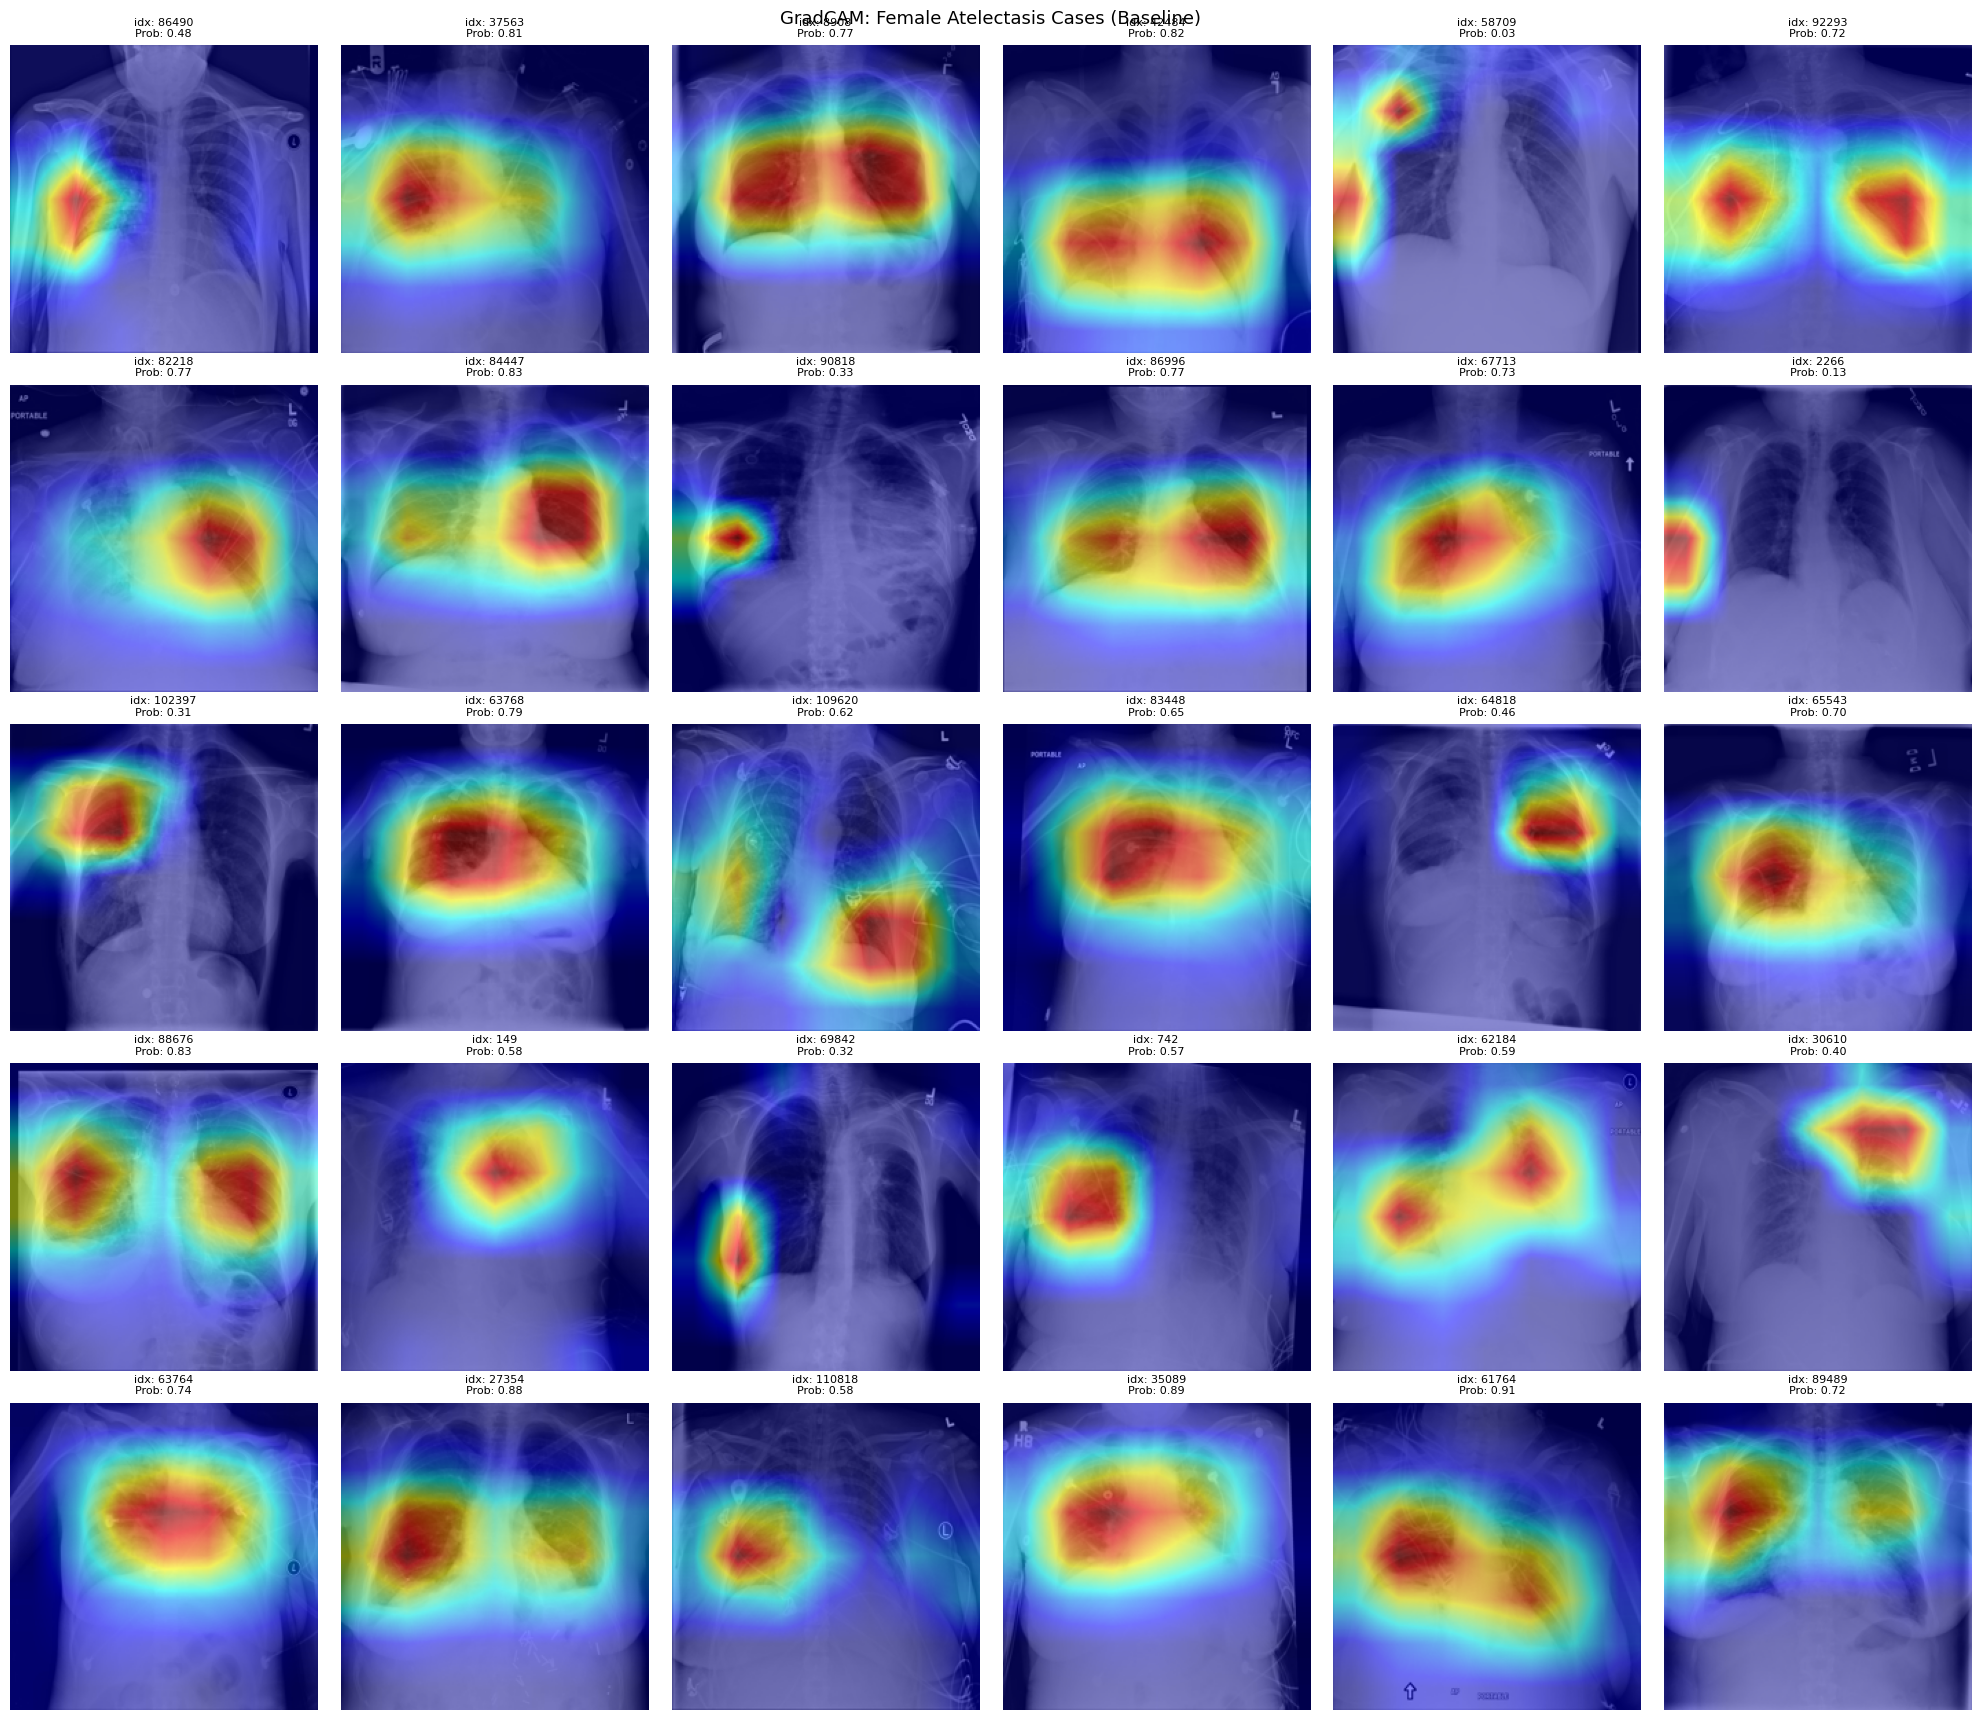

In [ ]:
model.eval()

# modify this line to retrieve female patients, male patients, older patients or younger patients
# male patients (test_df['tasks/patient sex'] == 1)
# older patients (test_df['patient_age'] > 50)
# younger patients (test_df['patient_age'] < 50)
test_cases = test_df[(test_df['tasks/atelectasis_label'] == 1) &(test_df['tasks/patient sex'] == 0)]

# display 30 images at once, change the random_state for different ones
example_df = test_cases.sample(n=30, random_state=1)

# display 6 images one row
n_cols = 6
n_rows = int(np.ceil(len(example_df) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, (_, row) in enumerate(example_df.iterrows()):
    original_index = row.name

    # load image
    tensor, img = load_image_from_hdf5(original_index)
    # get the heatmap
    cam = get_gradcam(model, tensor)
    # get the prediction
    prob = get_prediction(model, tensor)
    # overlay the image
    overlay = show_cam_on_image(img, cam, use_rgb=True)

    axes[i].imshow(overlay)
    axes[i].set_title(f"idx: {original_index}\nProb: {prob:.2f}", fontsize=8)
    axes[i].axis('off')


plt.suptitle('GradCAM: Female Atelectasis Cases (Baseline)', fontsize=13)
plt.tight_layout()
plt.show()

filepath                                                  images/068783.tiff
split                                                                   test
tasks/disease labels              [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
tasks/patient sex                                                          0
original_filepath                                    images/00016972_019.png
original_split                                                          test
patient_id                                                             16972
bounding_box               ['Atelectasis: (514.71186440678,634.8836235434...
disease labels                             Atelectasis|Effusion|Infiltration
finding_labels                             Atelectasis|Effusion|Infiltration
follow-up_nb                                                              19
original_image_size                                              (2500,2048)
original_pixel_spacing                                         (0.168,0.168)

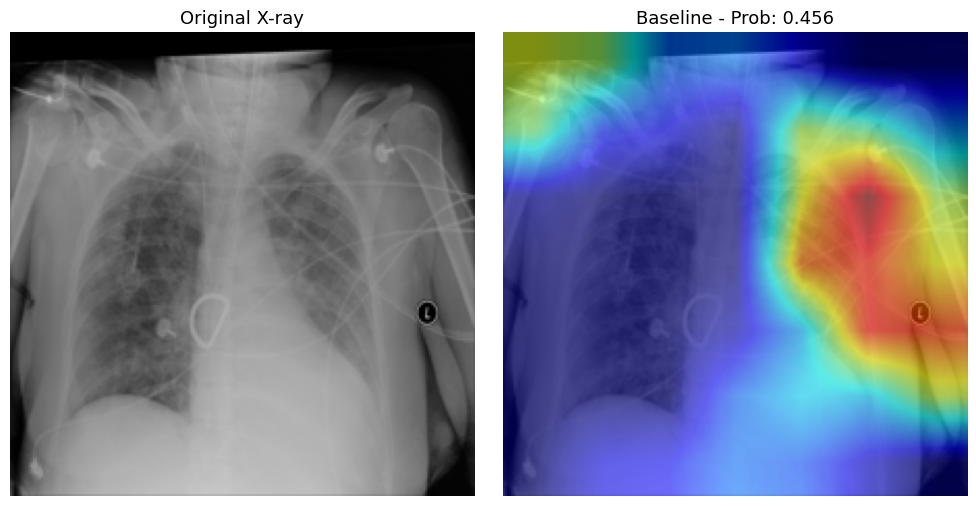

In [ ]:
# choose the index from the above image to compare with the original chest X-ray
compare_index = 68783
row = test_df.loc[compare_index]
# print the details of that X-ray
print(row)

tensor, img = load_image_from_hdf5(compare_index)
cam = get_gradcam(model, tensor)
prob = get_prediction(model, tensor)
overlay = show_cam_on_image(img, cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img)
axes[0].set_title('Original X-ray', fontsize=13)
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title(f'Baseline - Prob: {prob:.3f}', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()